In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Sketch creation**

In [ ]:
import os
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as F
from PIL import Image
from google.colab import drive
import time

# ========================
# SETUP
# ========================
drive.mount('/content/drive')

IMG_DIR = "/content/drive/MyDrive/Data/img1"
SKETCH_DIR = "/content/drive/MyDrive/data/sketches"

os.makedirs(SKETCH_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ========================
# TRANSFORMS
# ========================
transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor()
])

# ========================
# LOAD FILES
# ========================
files = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.jpg','.png','.jpeg'))]
total = len(files)

print(f"Total images: {total}")

start_time = time.time()

# ========================
# PROCESS LOOP
# ========================
for i, img_name in enumerate(files):
    img_path = os.path.join(IMG_DIR, img_name)
    save_path = os.path.join(SKETCH_DIR, img_name)

    try:
        # Load image
        img = Image.open(img_path).convert("RGB")

        # Transform → tensor → GPU
        img = transform(img).to(device)

        # Convert to grayscale
        gray = F.rgb_to_grayscale(img)

        # Sobel edge detection (GPU)
        sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32, device=device).view(1,1,3,3)
        sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=torch.float32, device=device).view(1,1,3,3)

        gray = gray.unsqueeze(0)

        edge_x = torch.nn.functional.conv2d(gray, sobel_x, padding=1)
        edge_y = torch.nn.functional.conv2d(gray, sobel_y, padding=1)

        edges = torch.sqrt(edge_x**2 + edge_y**2)

        # Normalize
        edges = edges / edges.max()

        # Convert back to CPU image
        edges = edges.squeeze().cpu()

        # Save image
        edge_img = T.ToPILImage()(edges)
        edge_img.save(save_path)

    except:
        continue

    # ========================
    # PROGRESS
    # ========================
    if i % 200 == 0:
        elapsed = time.time() - start_time
        speed = (i+1) / elapsed if elapsed > 0 else 0
        remaining = total - (i+1)
        eta = remaining / speed if speed > 0 else 0

        print(f"[{i+1}/{total}] Speed: {speed:.2f} img/s | ETA: {eta/60:.2f} min")

print("✅ GPU Sketch generation done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Total images: 6757
[1/6757] Speed: 0.94 img/s | ETA: 119.55 min
[201/6757] Speed: 30.21 img/s | ETA: 3.62 min
[401/6757] Speed: 33.21 img/s | ETA: 3.19 min
[601/6757] Speed: 15.27 img/s | ETA: 6.72 min
[801/6757] Speed: 6.38 img/s | ETA: 15.57 min
[1001/6757] Speed: 4.75 img/s | ETA: 20.19 min
[1201/6757] Speed: 4.01 img/s | ETA: 23.12 min
[1401/6757] Speed: 3.60 img/s | ETA: 24.76 min
[1601/6757] Speed: 3.36 img/s | ETA: 25.58 min
[1801/6757] Speed: 3.19 img/s | ETA: 25.86 min
[2001/6757] Speed: 3.07 img/s | ETA: 25.83 min
[2201/6757] Speed: 2.96 img/s | ETA: 25.61 min
[2401/6757] Speed: 2.89 img/s | ETA: 25.11 min
[2601/6757] Speed: 2.82 img/s | ETA: 24.52 min
[2801/6757] Speed: 2.77 img/s | ETA: 23.83 min
[3001/6757] Speed: 2.72 img/s | ETA: 23.02 min
[3201/6757] Speed: 2.72 img/s | ETA: 21.82 min
[3401/6757] Speed: 2.72 img/s | ETA: 20.

In [ ]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

**Train code**

In [ ]:
import torch
import os
import time
import gc
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import torch.nn.functional as F

from diffusers import AutoencoderKL, UNet2DConditionModel, ControlNetModel
from transformers import CLIPTokenizer, CLIPTextModel
from google.colab import drive
from skimage.metrics import structural_similarity as ssim

# ========================
# CLEAN MEMORY
# ========================
gc.collect()
torch.cuda.empty_cache()

# ========================
# SETUP
# ========================
drive.mount('/content/drive')

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

IMG_DIR = "/content/drive/MyDrive/data/img1"
SKETCH_DIR = "/content/drive/MyDrive/data/sketches"
MODEL_DIR = "/content/drive/MyDrive/models"

os.makedirs(MODEL_DIR, exist_ok=True)

# ========================
# TRANSFORMS
# ========================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # [-1, 1]
])

# ========================
# DATASET
# ========================
class SketchDataset(Dataset):
    def __init__(self, img_dir, sketch_dir):
        self.files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        self.img_dir = img_dir
        self.sketch_dir = sketch_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        sketch = Image.open(os.path.join(self.sketch_dir, name)).convert("RGB")

        return transform(img), transform(sketch)

dataset = SketchDataset(IMG_DIR, SKETCH_DIR)

# ========================
# SPLIT DATA
# ========================
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

# ========================
# LOAD MODELS (FP32 ONLY ✅)
# ========================
tokenizer = CLIPTokenizer.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="tokenizer"
)

text_encoder = CLIPTextModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="text_encoder"
).to(device)

vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae"
).to(device)

unet = UNet2DConditionModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="unet"
).to(device)

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny"
).to(device)

# ========================
# OPTIMIZATION
# ========================
unet.enable_gradient_checkpointing()
controlnet.enable_gradient_checkpointing()
torch.backends.cuda.matmul.allow_tf32 = True

# Freeze
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

controlnet.train()

optimizer = torch.optim.AdamW(controlnet.parameters(), lr=5e-7)

# AMP (NEW API)
scaler = torch.amp.GradScaler("cuda")

# ========================
# EVALUATION
# ========================
def evaluate():
    controlnet.eval()
    total_loss = 0
    total_ssim = 0

    with torch.no_grad():
        for img, sketch in test_loader:

            img = img.to(device)
            sketch = sketch.to(device)

            latents = vae.encode(img).latent_dist.sample()
            latents = (latents * 0.18215).clamp(-1, 1)

            noise = torch.randn_like(latents).clamp(-1, 1)
            timesteps = torch.randint(0, 1000, (1,), device=device).long()
            noisy_latents = latents + noise

            inputs = tokenizer(["fashion clothing"], padding="max_length", return_tensors="pt").to(device)
            text_embeddings = text_encoder(**inputs).last_hidden_state

            controlnet_output = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=text_embeddings,
                controlnet_cond=sketch,
                return_dict=True
            )

            noise_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=text_embeddings,
                down_block_additional_residuals=controlnet_output.down_block_res_samples,
                mid_block_additional_residual=controlnet_output.mid_block_res_sample
            ).sample

            loss = F.mse_loss(noise_pred, noise)
            total_loss += loss.item()

            pred = noise_pred[0].cpu().numpy()
            gt = noise[0].cpu().numpy()

            pred = np.transpose(pred, (1,2,0))
            gt = np.transpose(gt, (1,2,0))

            total_ssim += ssim(pred, gt, channel_axis=2, data_range=1.0)

    controlnet.train()
    return total_loss / len(test_loader), total_ssim / len(test_loader)

# ========================
# TRAINING LOOP
# ========================
EPOCHS = 1

for epoch in range(EPOCHS):
    epoch_loss = 0

    for i, (img, sketch) in enumerate(train_loader):

        img = img.to(device)
        sketch = sketch.to(device)

        with torch.no_grad():
            latents = vae.encode(img).latent_dist.sample()
            latents = (latents * 0.18215).clamp(-1, 1)

        noise = torch.randn_like(latents).clamp(-1, 1)
        timesteps = torch.randint(0, 1000, (1,), device=device).long()
        noisy_latents = latents + noise

        with torch.no_grad():
            inputs = tokenizer(["fashion clothing"], padding="max_length", return_tensors="pt").to(device)
            text_embeddings = text_encoder(**inputs).last_hidden_state

        # AMP forward
        with torch.amp.autocast("cuda"):
            controlnet_output = controlnet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=text_embeddings,
                controlnet_cond=sketch,
                return_dict=True
            )

            noise_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=text_embeddings,
                down_block_additional_residuals=controlnet_output.down_block_res_samples,
                mid_block_additional_residual=controlnet_output.mid_block_res_sample
            ).sample

            loss = F.mse_loss(noise_pred, noise)

        if torch.isnan(loss):
            print("⚠️ NaN skipped")
            continue

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(controlnet.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        if i % 100 == 0:
            print(f"Epoch {epoch} | Step {i} | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)

    # SAVE CHECKPOINT
    torch.save(controlnet.state_dict(), f"{MODEL_DIR}/controlnet_epoch_{epoch}.pth")

    # EVALUATE
    test_loss, test_ssim = evaluate()

    print(f"\n✅ Epoch {epoch}")
    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"SSIM: {test_ssim:.4f}")

print("🎉 Training Complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Train: 5405 | Test: 1352


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


KeyboardInterrupt: 

**Evaluation code**

In [ ]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.metrics import structural_similarity as ssim
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn.functional as F

from diffusers import AutoencoderKL, UNet2DConditionModel, ControlNetModel
from transformers import CLIPTokenizer, CLIPTextModel

# ========================
# DEVICE
# ========================
device = "cuda" if torch.cuda.is_available() else "cpu"

IMG_DIR = "/content/drive/MyDrive/data/img1"
SKETCH_DIR = "/content/drive/MyDrive/data/sketches"
MODEL_PATH = "/content/drive/MyDrive/models/controlnet_epoch_0.pth"

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ========================
# DATASET
# ========================
class SketchDataset(Dataset):
    def __init__(self, img_dir, sketch_dir):
        self.files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png','.jpeg'))]
        self.img_dir = img_dir
        self.sketch_dir = sketch_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = Image.open(os.path.join(self.img_dir, name)).convert("RGB")
        sketch = Image.open(os.path.join(self.sketch_dir, name)).convert("RGB")

        return transform(img), transform(sketch)

dataset = SketchDataset(IMG_DIR, SKETCH_DIR)

# SAME SPLIT AS TRAINING
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

_, test_dataset = random_split(dataset, [train_size, test_size])

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Test size: {len(test_dataset)}")

# ========================
# LOAD MODELS
# ========================
tokenizer = CLIPTokenizer.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="tokenizer"
)

text_encoder = CLIPTextModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="text_encoder"
).to(device)

vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae"
).to(device)

unet = UNet2DConditionModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="unet"
).to(device)

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny"
).to(device)

# LOAD YOUR MODEL
controlnet.load_state_dict(torch.load(MODEL_PATH, map_location=device))
controlnet.eval()

# ========================
# METRICS
# ========================
ssim_scores = []
psnr_scores = []
accuracies = []

all_preds = []
all_labels = []

# ========================
# EVALUATION
# ========================
with torch.no_grad():
    for i, (img, sketch) in enumerate(test_loader):

        img = img.to(device)
        sketch = sketch.to(device)

        latents = vae.encode(img).latent_dist.sample()
        latents = latents * 0.18215

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, 1000, (1,), device=device).long()
        noisy_latents = latents + noise

        inputs = tokenizer(["fashion clothing"], padding="max_length", return_tensors="pt").to(device)
        text_embeddings = text_encoder(**inputs).last_hidden_state

        controlnet_output = controlnet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=text_embeddings,
            controlnet_cond=sketch,
            return_dict=True
        )

        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=text_embeddings,
            down_block_additional_residuals=controlnet_output.down_block_res_samples,
            mid_block_additional_residual=controlnet_output.mid_block_res_sample
        ).sample

        pred = noise_pred[0].cpu().numpy()
        gt = noise[0].cpu().numpy()

        pred = np.transpose(pred, (1,2,0))
        gt = np.transpose(gt, (1,2,0))

        # SSIM
        ssim_scores.append(ssim(pred, gt, channel_axis=2, data_range=1.0))

        # PSNR
        mse = np.mean((pred - gt) ** 2)
        psnr = 20 * np.log10(1.0 / np.sqrt(mse + 1e-8))
        psnr_scores.append(psnr)

        # Accuracy
        pred_bin = (pred > 0.1).astype(int)
        gt_bin = (gt > 0.1).astype(int)

        accuracies.append((pred_bin == gt_bin).mean())

        all_preds.extend(pred_bin.flatten())
        all_labels.extend(gt_bin.flatten())

        # Show few samples
        if i < 3:
            plt.figure(figsize=(8,3))
            plt.subplot(1,2,1)
            plt.title("Pred")
            plt.imshow(pred[:,:,0], cmap='gray')
            plt.subplot(1,2,2)
            plt.title("GT")
            plt.imshow(gt[:,:,0], cmap='gray')
            plt.show()

# ========================
# RESULTS
# ========================
print("SSIM:", np.mean(ssim_scores))
print("PSNR:", np.mean(psnr_scores))
print("Accuracy:", np.mean(accuracies))

# ========================
# CONFUSION MATRIX
# ========================
cm = confusion_matrix(all_labels, all_preds)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ========================
# GRAPHS
# ========================
plt.plot(ssim_scores)
plt.title("SSIM Trend")
plt.show()

plt.plot(psnr_scores)
plt.title("PSNR Trend")
plt.show()

plt.plot(accuracies)
plt.title("Accuracy Trend")
plt.show()

**Results**

In [16]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

# ========================
# DEVICE
# ========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ========================
# LOAD CONTROLNET
# ========================
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny"
)

controlnet.load_state_dict(
    torch.load("/content/drive/MyDrive/sketch_model/controlnet_epoch_0.pth", map_location=device)
)

controlnet = controlnet.to(device).half()   # 🔥 IMPORTANT

# ========================
# LOAD PIPELINE
# ========================
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to(device)

pipe.enable_attention_slicing()



Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
from google.colab import files
from PIL import Image

# ========================
# UPLOAD FROM DEVICE
# ========================
print("Upload your sketch image:")
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")
image = image.resize((512, 512))

Upload your sketch image:


Saving MEN-Shirts_Polos-id_00005833-01_1_front.jpg to MEN-Shirts_Polos-id_00005833-01_1_front.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

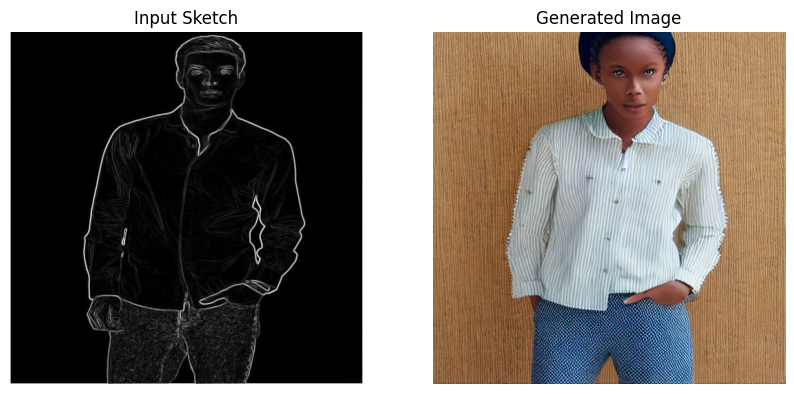

In [26]:


# ========================
# PROMPT
# ========================
prompt = "add the best fashion related to girl cloths"

# ========================
# GENERATE IMAGE
# ========================
with torch.autocast("cuda"):
    output = pipe(
        prompt=prompt,
        image=image,
        num_inference_steps=20
    )

result = output.images[0]

# ========================
# SHOW RESULT
# ========================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Sketch")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Generated Image")
plt.imshow(result)
plt.axis("off")

plt.show()



In [27]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

# ========================
# DEVICE
# ========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ========================
# LOAD ORIGINAL CONTROLNET (NO FINETUNE)
# ========================
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny"
).to(device).half()

# ========================
# LOAD PIPELINE
# ========================
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to(device)

pipe.enable_attention_slicing()



Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
from google.colab import files
from PIL import Image

# ========================
# UPLOAD FROM DEVICE
# ========================
print("Upload your sketch image:")
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")
image = image.resize((512, 512))



Upload your sketch image:


Saving MEN-Shirts_Polos-id_00005833-01_1_front.jpg to MEN-Shirts_Polos-id_00005833-01_1_front (1).jpg


  0%|          | 0/20 [00:00<?, ?it/s]

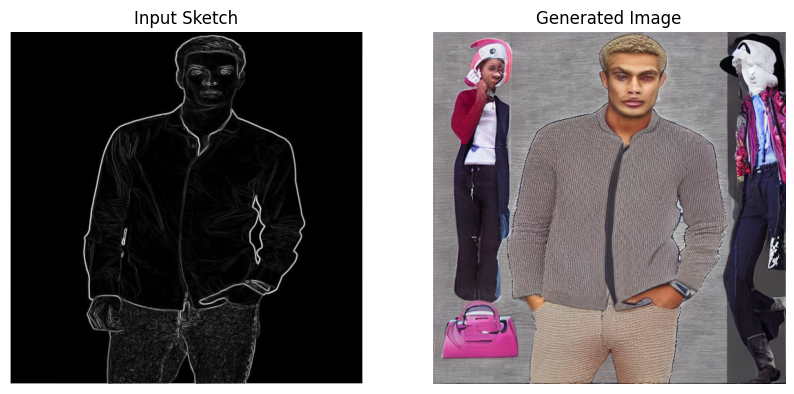

In [29]:


# ========================
# PROMPT
# ========================
prompt = "add the best fashion related cloths"

# ========================
# GENERATE IMAGE
# ========================
with torch.autocast("cuda"):
    output = pipe(
        prompt=prompt,
        image=image,
        num_inference_steps=20
    )

result = output.images[0]

# ========================
# SHOW RESULT
# ========================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Sketch")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Generated Image")
plt.imshow(result)
plt.axis("off")

plt.show()

